In [163]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [164]:
def get_freq_recoding(n):

    values = np.linspace(0.0, 1.0 / (2.0 * 1.0 / (n * 2)), n)
    keys = [f"p_{i}" for i in range(n)]
    return pd.Series(data=values, index=keys)

In [165]:
path="../../data/numerical_rep/fft"
properties = {
    "Molecular weight": "FASG760101",
    "Positive charge": "FAUJ880111",
    "Negative charge": "FAUJ880112",
    "Net charge": "KLEP840101",
    "Hydrophobicity ": "JOND750101",
    "Isoelectric point": "ZIMJ680104",
    "Loop": "ROBB760113",
    "Alpha": "GEIM800101",
    "Beta": "GEIM800105"
}

In [166]:
dataframes = []
for name, prop in properties.items():
    df = pd.read_csv(f"{path}/fft_antiviral_homology_90_{prop}.csv")
    df["property"] = name
    dataframes.append(df)

In [167]:
dataframes

[          p_0          p_1          p_2         p_3         p_4         p_5  \
 0     1036.11  1005.379312   916.644692  779.832068  610.071766  425.861998   
 1     3756.10  2682.875529   537.583223  810.185342  560.674558  320.453886   
 2      973.03   942.692319   855.230646  720.897088  555.581471  379.726991   
 3     5573.19  2175.072025  1155.086349  190.202151  504.403051  293.183918   
 4     2845.39  2416.107207  1358.888004  237.839435  535.678519  642.354099   
 ...       ...          ...          ...         ...         ...         ...   
 1308  2771.06  2329.455253  1246.767358  132.369920  619.485215  656.840481   
 1309  2724.11  2386.480223  1519.455027  486.210115  318.324041  646.685723   
 1310  2724.11  2386.480223  1519.455027  486.210115  318.324041  646.685723   
 1311  2724.11  2386.480223  1519.455027  486.210115  318.324041  646.685723   
 1312  1065.13  1026.838876   916.608367  747.783713  540.836220  321.706649   
 
              p_6         p_7         

In [168]:
dataframes = pd.concat(dataframes, ignore_index=True)
dataframes.drop(columns=["experimental_characteristics"], inplace=True)
n_cols= [col for col in dataframes.columns if col.startswith("p_")]
freq=get_freq_recoding(len(n_cols))
print(n_cols)
print(len(n_cols))

['p_0', 'p_1', 'p_2', 'p_3', 'p_4', 'p_5', 'p_6', 'p_7', 'p_8', 'p_9', 'p_10', 'p_11', 'p_12', 'p_13', 'p_14', 'p_15', 'p_16', 'p_17', 'p_18', 'p_19', 'p_20', 'p_21', 'p_22', 'p_23', 'p_24', 'p_25', 'p_26', 'p_27', 'p_28', 'p_29', 'p_30', 'p_31']
32


In [169]:
df_long = df.melt(id_vars=["target", "property"], 
                  value_vars=n_cols,
                  var_name="frequency",
                  value_name="value")

In [170]:
df_long["frequency"] = df_long["frequency"].replace(freq).astype(float)

/tmp/ipykernel_104052/3472810620.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long["frequency"] = df_long["frequency"].replace(freq).astype(float)


In [171]:
df_long

,target,property,frequency,value
0,1,Beta,0.0,8.890000
1,1,Beta,0.0,27.060000
2,1,Beta,0.0,8.930000
3,1,Beta,0.0,47.220000
4,1,Beta,0.0,19.060000
...,...,...,...,...
42011,1,Beta,32.0,1.808114
42012,0,Beta,32.0,2.807670
42013,1,Beta,32.0,2.807670
42014,2,Beta,32.0,2.807670


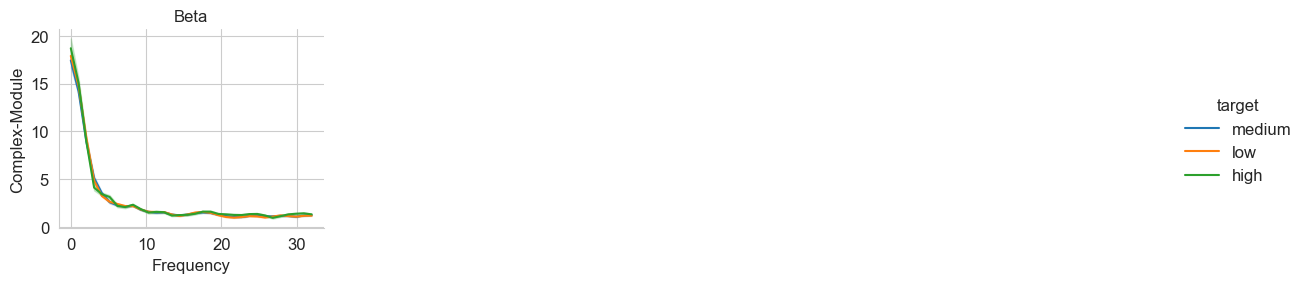

In [172]:
df_long["target"] = df_long["target"].map({0: "low", 1: "medium", 2: "high"})

sns.relplot(
    data=df_long,
    x="frequency",
    y="value",
    hue="target",
    col="property",
    col_wrap=4,
    kind="line",
    facet_kws={"sharey": False},
    height=3,
).set_titles(col_template="{col_name}").set_xlabels("Frequency").set_ylabels("Complex-Module")

plt.show()